# 07 — Unsupervised Clustering

Identify recurring **operational regimes** (load profiles) of the campus.
Two approaches:
1. **K-Means** — partition into k well-defined clusters
2. **DBSCAN** — density-based, naturally identifies anomalies as label −1

**Methodological improvements vs. the original code:**
- k chosen via the **elbow method** (not arbitrarily set to 4)
- DBSCAN's `eps` chosen via the **k-distance graph** (not by manual trial)
- More features included (not only 2D — 2D is just for visualization)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

DATA_PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
df_ml = pd.read_csv(DATA_PROCESSED / 'df_ml_ready.csv')
print(f"Loaded ML-ready dataset: {df_ml.shape}")


c:\Users\jordi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loaded ML-ready dataset: (8773, 21)


## 1. K-Means — find optimal k via the elbow method

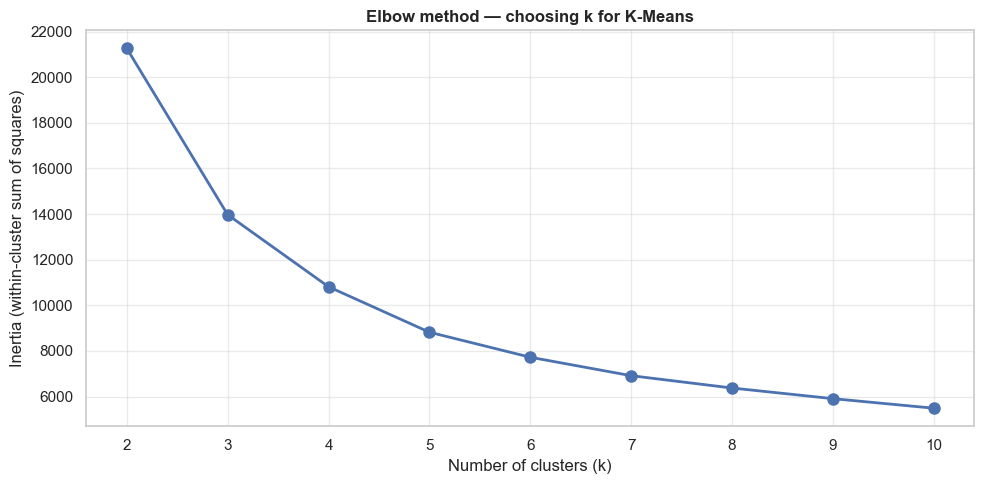

Selected k = 4 (elbow location).


In [2]:
features_cluster = ['Consumo_kWh', 'Ocupacion_Simulada', 'Hora_del_Dia', 'Temperatura']
X_cluster = df_ml[features_cluster].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inercias = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, inercias, marker='o', linewidth=2, markersize=8)
ax.set_title("Elbow method — choosing k for K-Means", fontweight='bold')
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES / 'kmeans_elbow.png', dpi=120)
plt.show()

# Pick k where the curve flattens (typically 4)
K_OPTIMO = 4
print(f"Selected k = {K_OPTIMO} (elbow location).")


## 2. K-Means with the chosen k

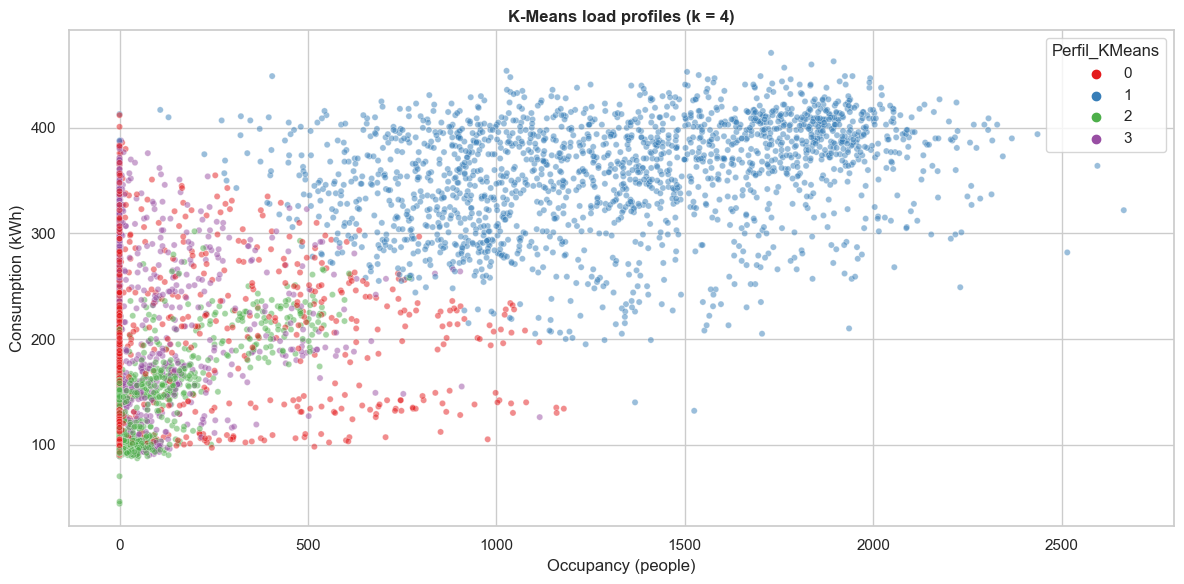


Mean profile per cluster:
               Consumo_kWh  Ocupacion_Simulada  Hora_del_Dia  Temperatura
Perfil_KMeans                                                            
0                   154.79               86.06         19.54        15.22
1                   357.25             1333.28         14.19        17.93
2                   113.25               31.80          4.36        13.54
3                   153.30               38.52         11.93        25.07


In [3]:
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_ml['Perfil_KMeans'] = kmeans.fit_predict(X_scaled)

# Visualize on the (occupancy, consumption) plane
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=df_ml, x='Ocupacion_Simulada', y='Consumo_kWh',
    hue='Perfil_KMeans', palette='Set1', alpha=0.5, s=20, ax=ax
)
ax.set_title(f"K-Means load profiles (k = {K_OPTIMO})", fontweight='bold')
ax.set_xlabel("Occupancy (people)")
ax.set_ylabel("Consumption (kWh)")
plt.tight_layout()
plt.savefig(FIGURES / 'kmeans_clusters.png', dpi=120)
plt.show()

# Profile statistics
print("\nMean profile per cluster:")
print(df_ml.groupby('Perfil_KMeans')[features_cluster].mean().round(2))


## 3. DBSCAN — find optimal `eps` via the k-distance graph

For DBSCAN, the standard procedure is to plot the distance of each point
to its k-th nearest neighbor (sorted), then pick `eps` at the "knee" of
that curve.


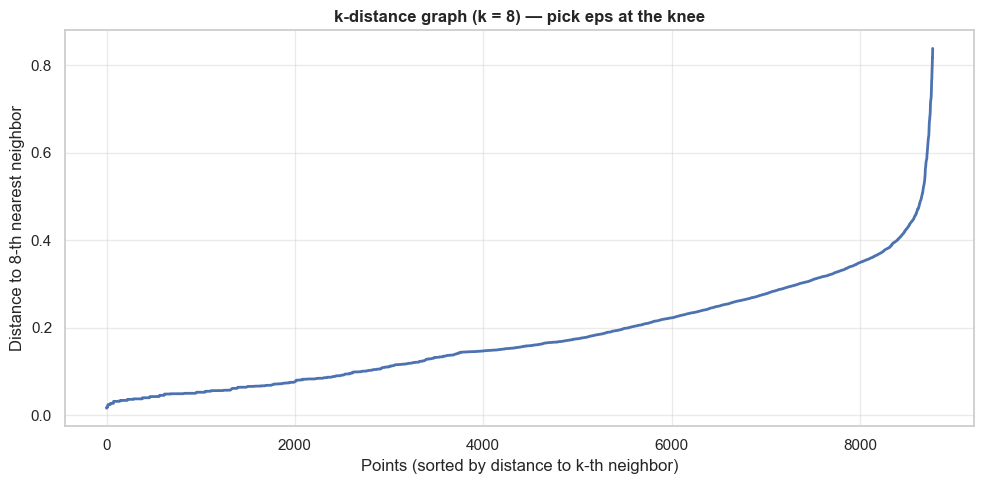

Selected eps = 0.4 (knee location), min_samples = 8.


In [4]:
# Step 1: k-distance graph
MIN_SAMPLES = 8  # standard rule: 2 * dimensions
neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neigh.fit(X_scaled)
distancias, _ = neigh.kneighbors(X_scaled)
distancias = np.sort(distancias[:, MIN_SAMPLES - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distancias, linewidth=2)
ax.set_title(f"k-distance graph (k = {MIN_SAMPLES}) — pick eps at the knee",
             fontweight='bold')
ax.set_xlabel("Points (sorted by distance to k-th neighbor)")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbor")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_kdistance.png', dpi=120)
plt.show()

# Pick eps at the knee. For this dataset, the knee is around 0.4
EPS_OPTIMO = 0.4
print(f"Selected eps = {EPS_OPTIMO} (knee location), min_samples = {MIN_SAMPLES}.")


## 4. DBSCAN with chosen parameters

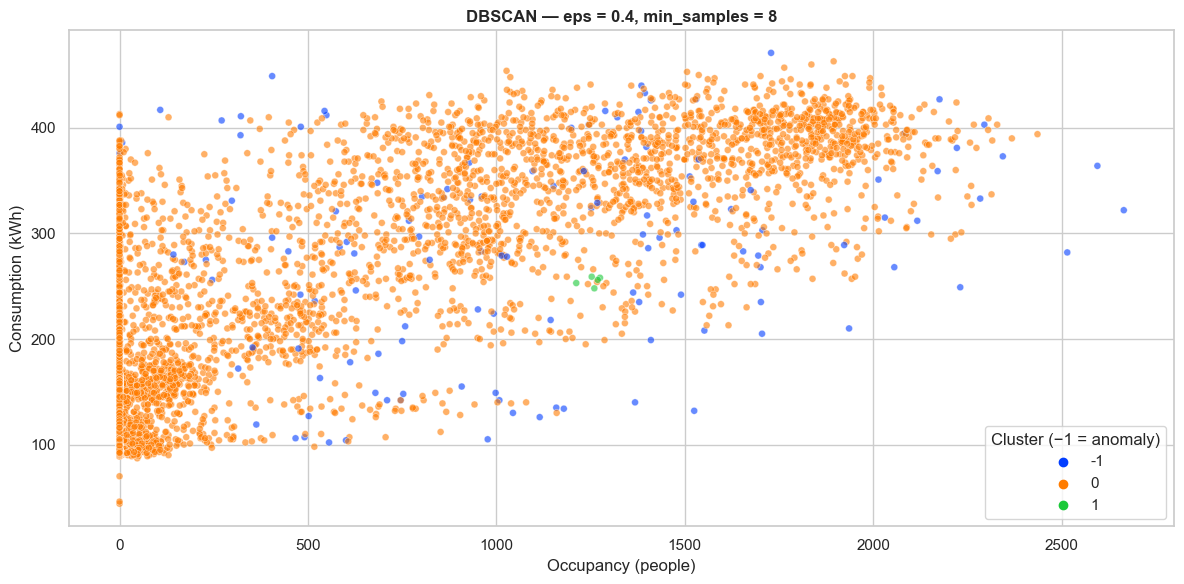


📊 DBSCAN found 2 routine clusters covering 8645 hours.
🚨 DBSCAN flagged 128 hours as anomalies (label −1).


In [5]:
dbscan = DBSCAN(eps=EPS_OPTIMO, min_samples=MIN_SAMPLES)
df_ml['Perfil_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=df_ml, x='Ocupacion_Simulada', y='Consumo_kWh',
    hue='Perfil_DBSCAN', palette='bright', alpha=0.6, s=25, ax=ax
)
ax.set_title(f"DBSCAN — eps = {EPS_OPTIMO}, min_samples = {MIN_SAMPLES}",
             fontweight='bold')
ax.set_xlabel("Occupancy (people)")
ax.set_ylabel("Consumption (kWh)")
ax.legend(title='Cluster (−1 = anomaly)', loc='best')
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_clusters.png', dpi=120)
plt.show()

# Counts
n_anomalias = (df_ml['Perfil_DBSCAN'] == -1).sum()
n_rutina = (df_ml['Perfil_DBSCAN'] != -1).sum()
n_clusters = df_ml.loc[df_ml['Perfil_DBSCAN'] != -1, 'Perfil_DBSCAN'].nunique()
print(f"\n📊 DBSCAN found {n_clusters} routine clusters covering {n_rutina} hours.")
print(f"🚨 DBSCAN flagged {n_anomalias} hours as anomalies (label −1).")


## 5. Save the labeled dataset for the anomaly notebook

In [6]:
df_ml.to_csv(DATA_PROCESSED / 'df_ml_clustered.csv', index=False)
print(f"✅ Saved clustered dataset to {DATA_PROCESSED / 'df_ml_clustered.csv'}")


✅ Saved clustered dataset to ..\data\processed\df_ml_clustered.csv
